# Fantasy Football Hierarchical Bayesian Inference

## Imports

In [2]:
import math
import nfldb
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import seaborn as sns
import numpy as np
import pandas as pd
import theano.tensor as tt
import pymc3 as pm
from IPython.core.debugger import Tracer

## Data Import and Munging

### nfldb
Create data base with passing yards for the 2015 regular season with nfldb

In [3]:
# selftart up nfldb
db = nfldb.connect()
q = nfldb.Query(db)
season_year = 2015
season_type = 'Regular'
# play id
q.game(season_year=season_year, season_type=season_type)
# plays = g.as_plays()

# initialize
home_team = []
away_team = []
gamekey   = []
home_yds = []
away_yds = []
week = []
num_games = 0

# loop through games
for i in range(1,18):
    # find out who plays who
    q = nfldb.Query(db).game(season_year=season_year,season_type=season_type,week=i)
    for g in q.as_games():
        home_team.append(g.home_team)
        away_team.append(g.away_team)
        gamekey.append(g.gamekey)
        week.append(i)
        num_games += 1

# cycle through each playplayer for yards
for i in range(0, num_games):
    # home team yards
    q = nfldb.Query(db).game(gamekey=gamekey[i],team=home_team[i])
    q.play_player(team=home_team[i])
    pps = q.as_aggregate()
    home_yds.append(sum(pp.passing_yds for pp in pps))
          
    # away team yards
    q = nfldb.Query(db).game(gamekey=gamekey[i],team=away_team[i])
    q.play_player(team=away_team[i])
    pps = q.as_aggregate()
    away_yds.append(sum(pp.passing_yds for pp in pps))

# save to a new dataframe
df = pd.DataFrame({'home_team':home_team,
                   'away_team':away_team,
                   'home_yds':home_yds,
                   'away_yds':away_yds,
                   'week':week,
                   'gamekey':gamekey})

### Munging
Create a look-up table for team names

In [4]:
teams = df.home_team.unique()
teams = pd.DataFrame(teams, columns=['team'])
teams['i'] = teams.index
teams.head()
teams.to_csv('teams.csv')

Create away and home columns

In [5]:
df = pd.merge(df, teams, left_on='home_team', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_home'}).drop('team', 1)
df = pd.merge(df, teams, left_on='away_team', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_away'}).drop('team', 1)
num_teams = len(df.i_home.drop_duplicates())
df.to_csv('out.csv')
df.head()

  away_team  away_yds gamekey home_team  home_yds  week  i_home  i_away
0       TEN       209   56515        TB       210     1       0      29
1       BAL       117   56513       DEN       175     1       1      28
2       DET       246   56512        SD       404     1       2      27
3       IND       243   56504       BUF       195     1       3      20
4        KC       243   56506       HOU       334     1       4      21

## Modeling
### Priors

In [6]:
model = pm.Model()
with pm.Model() as model:
    # global model parameters
    home       = pm.Normal('home',      0, tau=.0001)
    tau_att    = pm.Gamma('tau_att',   .1, .1)
    tau_def    = pm.Gamma('tau_def',   .1, .1)
    intercept  = pm.Normal('intercept', 0, tau=.0001)
    #team-specific parameters
    atts_star  = pm.Normal('atts_star',
                           mu    = 0,
                           tau   = tau_att,
                           shape = num_teams)
    defs_star  = pm.Normal('defs_star',
                           mu    = 0,
                           tau   = tau_def,
                           shape = num_teams)

In [0]:
### Constraints

In [7]:
with model:
    atts       = pm.Deterministic('atts', atts_star - tt.mean(atts_star))
    defs       = pm.Deterministic('defs', defs_star - tt.mean(defs_star))
    home_theta = tt.exp(intercept + home + atts[df.i_home.values] + defs[df.i_away.values])
    away_theta = tt.exp(intercept + atts[df.i_away.values] + defs[df.i_home.values])

### Update beleifs with observations

In [8]:
with model:
    # likelihood of observed data
    home_yds = pm.Poisson('home_yds',
                          mu=home_theta,
                          observed=df.home_yds.values)
    away_yds = pm.Poisson('away_yds',
                          mu=away_theta,
                          observed=df.away_yds.values)

## Sampling

         Current function value: 5906.599874
         Iterations: 95
         Function evaluations: 224
         Gradient evaluations: 213


  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 25/20000 [00:00<01:20, 249.05it/s]

  0%|          | 38/20000 [00:00<01:44, 190.34it/s]

  0%|          | 47/20000 [00:00<02:21, 140.73it/s]

...

 99%|█████████▉| 19878/20000 [00:48<00:00, 488.37it/s]

100%|█████████▉| 19928/20000 [00:48<00:00, 476.30it/s]

100%|█████████▉| 19977/20000 [00:48<00:00, 480.16it/s]

100%|██████████| 20000/20000 [00:48<00:00, 411.28it/s]

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x11e0b2450>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x1228e7450>]], dtype=object)

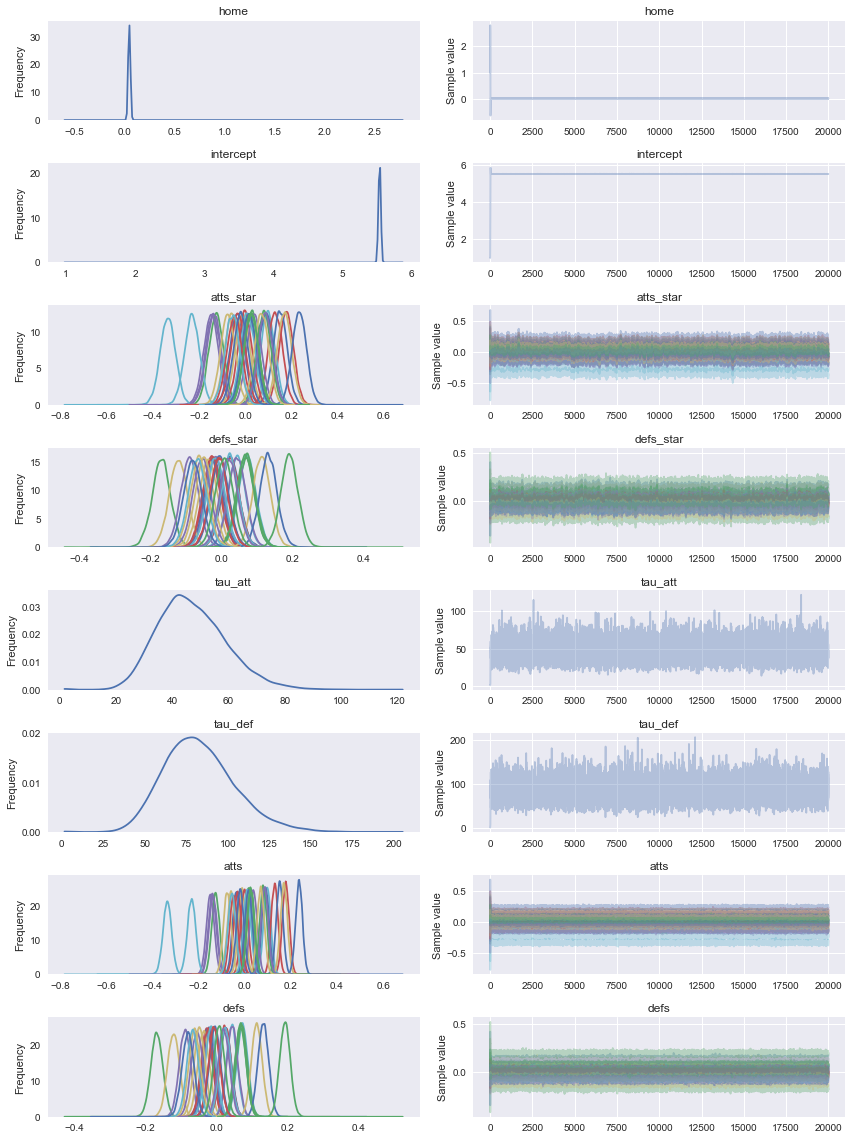

In [9]:
with model:
    start = pm.find_MAP()
    step = pm.NUTS(state=start)
    trace = pm.sample(20000,step,init=start)
pm.traceplot(trace)

In [0]:
## Results
### Convergence

(array([  1.60000000e+01,   0.00000000e+00,   3.00000000e+00,
          6.30000000e+01,   3.30000000e+02,   9.96000000e+02,
          1.95200000e+03,   2.81500000e+03,   3.30000000e+03,
          3.01400000e+03,   2.57800000e+03,   1.95800000e+03,
          1.30200000e+03,   7.71000000e+02,   4.57000000e+02,
          2.27000000e+02,   1.20000000e+02,   5.20000000e+01,
          2.70000000e+01,   1.00000000e+01,   7.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   1.00000000e+00,
          1.00000000e+00]),
 array([   1.79279745,    6.595742  ,   11.39868656,   16.20163111,
          21.00457567,   25.80752022,   30.61046477,   35.41340933,
          40.21635388,   45.01929844,   49.82224299,   54.62518755,
          59.4281321 ,   64.23107666,   69.03402121,   73.83696577,
          78.63991032,   83.44285488,   88.24579943,   93.04874399,
          97.85168854,  102.6546331 ,  107.45757765,  112.26052221,
         117.06346676,  121.86641132]),
 <a list of 1 Patch objects>

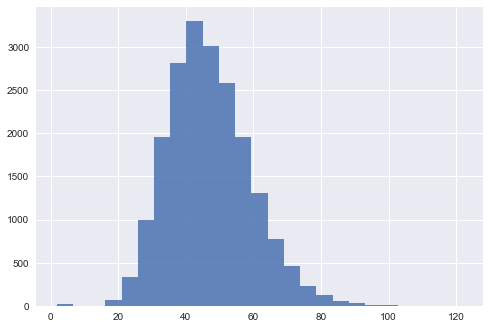

In [10]:
plt.hist(trace['tau_att'], histtype='stepfilled', bins=25, alpha=0.85)

### Confidence Intervals

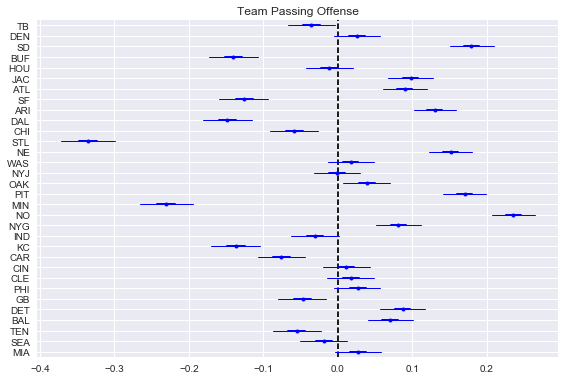

In [11]:
pm.forestplot(trace, varnames=['atts'], ylabels=teams['team'], main="Team Passing Offense")

### Defense strength

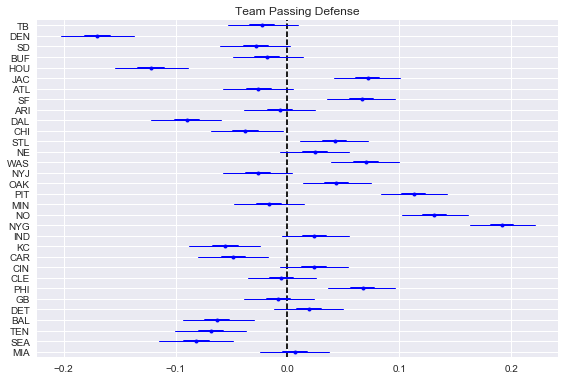

In [13]:
pm.forestplot(trace, varnames=['defs'], ylabels=teams['team'], main="Team Passing Defense")

# Simulation
## Define simulation

In [14]:
    def simulate_season():
        """
        Simulate a season once, using one random draw from the mcmc chain.
        """
        num_samples = trace['atts'].shape[0]
        draw = np.random.randint(0, num_samples)
        atts_draw = pd.DataFrame({'att': trace['atts'][draw, :],})
        defs_draw = pd.DataFrame({'def': trace['defs'][draw, :],})
        home_draw = trace['home'][draw]
        intercept_draw = trace['intercept'][draw]
        season = df.copy()
        season = pd.merge(season, atts_draw, left_on='i_home', right_index=True)
        season = pd.merge(season, defs_draw, left_on='i_home', right_index=True)
        season = season.rename(columns = {'att': 'att_home', 'def': 'def_home'})
        season = pd.merge(season, atts_draw, left_on='i_away', right_index=True)
        season = pd.merge(season, defs_draw, left_on='i_away', right_index=True)
        season = season.rename(columns = {'att': 'att_away', 'def': 'def_away'})
        season['home'] = home_draw
        season['intercept'] = intercept_draw
        season['home_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                          x['home'] +
                                                          x['att_home'] +
                                                          x['def_away']), axis=1)
        season['away_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                          x['att_away'] +
                                                          x['def_home']), axis=1)

        season['home_yds'] = season.apply(lambda x: np.random.poisson(x['home_theta']), axis=1)

        season['away_yds'] = season.apply(lambda x: np.random.poisson(x['away_theta']), axis=1)
        return season

    def create_season_table(season):
        '''
        use dataframe output of simulate_season to creat summary season table
        '''
        g = season.groupby('i_home')
        home = pd.DataFrame({'home_yds': g.home_yds.sum(),
                             'home_yds_against': g.away_yds.sum(),
                             })
        g = season.groupby('i_away')
        away = pd.DataFrame({'away_yds': g.away_yds.sum(),
                             'away_yds_against': g.home_yds.sum(),
                             })
        df = home.join(away)
        df['yf'] = df.home_yds + df.away_yds
        df['ya'] = df.home_yds_against + df.away_yds_against
        df = pd.merge(teams, df, left_on='i', right_index=True)
        return df

    def simulate_seasons(n):
        dfs = []
        for i in range(n):
            s = simulate_season()
            t = create_season_table(s)
            t['iteration'] = i
            dfs.append(t)
        return pd.concat(dfs, ignore_index=True)

## Execute simulations

In [15]:
simuls = simulate_seasons(1000)

## View simulation for a single team

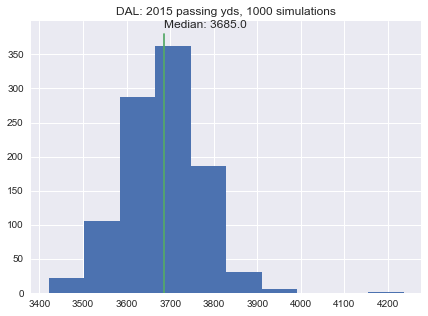

In [16]:
team_name = 'DAL'
ax = simuls.yf[simuls.team == team_name].hist(figsize=(7,5))
median = simuls.yf[simuls.team == team_name].median()
ax.set_title(team_name + ': 2015 passing yds, 1000 simulations')
ax.plot([median, median], ax.get_ylim())
plt.annotate('Median: %s' % median, xy=(median + 1, ax.get_ylim()[1]-10))

## View results for all teams

/usr/local/lib/python2.7/site-packages/ipykernel/__main__.py:16: FutureWarning: by argument to sort_index is deprecated, pls use .sort_values(by=...)


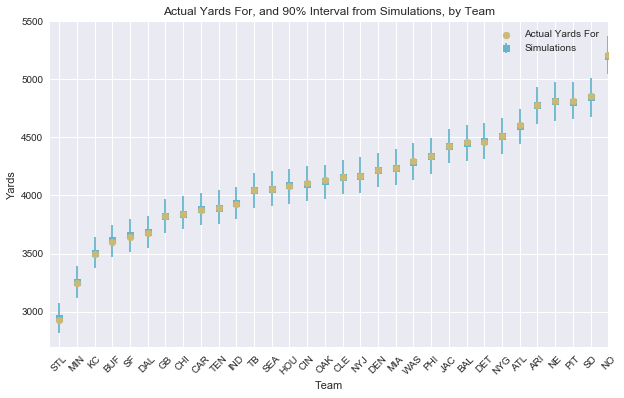

In [17]:
df_observed = create_season_table(df)
g = simuls.groupby('team')
season_hdis = pd.DataFrame({'yds_for_lower': g.yf.quantile(.05),
                            'yds_for_median': g.yf.median(),
                            'yds_for_upper': g.yf.quantile(.95),
                            'yds_against_lower': g.ya.quantile(.05),
                            'yds_against_upper': g.ya.quantile(.95),
})

season_hdis = pd.merge(season_hdis, df_observed, left_index=True, right_on='team')
column_order = ['team', 'yds_for_lower', 'yf', 'yds_for_median', 'yds_for_upper',
                'yds_against_lower', 'ya', 'yds_against_upper',]
season_hdis = season_hdis[column_order]
season_hdis['relative_yds_upper'] = season_hdis.yds_for_upper - season_hdis.yds_for_median
season_hdis['relative_yds_lower'] = season_hdis.yds_for_median - season_hdis.yds_for_lower
season_hdis = season_hdis.sort_index(by='yf')
season_hdis = season_hdis.reset_index()
season_hdis['x'] = season_hdis.index + .5
season_hdis

fig, axs = plt.subplots(figsize=(10,6))
axs.scatter(season_hdis.x, season_hdis.yf, c=sns.palettes.color_palette()[4], zorder = 10, label='Actual Yards For')
axs.errorbar(season_hdis.x, season_hdis.yds_for_median,
             yerr=(season_hdis[['relative_yds_lower', 'relative_yds_upper']].values).T,
             fmt='s', c=sns.palettes.color_palette()[5], label='Simulations')
axs.set_title('Actual Yards For, and 90% Interval from Simulations, by Team')
axs.set_xlabel('Team')
axs.set_ylabel('Yards')
axs.set_xlim(0, 20)
axs.legend()
_= axs.set_xticks(season_hdis.index + .5)
_= axs.set_xticklabels(season_hdis['team'].values, rotation=45)